# Minor Road AADT Estimation via Routing Importance

Replication of Morley & Gulliver (2016) *Methods to improve traffic flow and noise
exposure estimation on minor roads* using pgRouting on England OSM data.

## Methodology Overview

**Regression equation** (Morley & Gulliver, 2016, Eq. 1):

```
AADT ~ log(routing_importance) + road_class + log(nearest_major_AADT) + urban/rural
```

**Data sources:**
- **Road network:** OpenStreetMap England (imported via osm2po → pgRouting)
- **Training data:** DfT AADF minor road count points (n ≈ 4,400 nationally)
- **Urban/rural:** ONS Output Area Rural-Urban Classification (2021 Census)

**Pipeline:**

| Step | Section | Description |
|---|---|---|
| 1 | §2–3 | Classify OSM roads as major/minor; create pgRouting topology |
| 2 | §4–5 | Polygonize major roads into enclosed zones; identify coastal roads |
| 3 | §6 | Zone-based Dijkstra routing → edge traversal counts |
| 4 | §7 | Standardize traversals by zone size → routing importance index |
| 5 | §8 | Export routed network from PostGIS |
| 6 | §9–10 | Match DfT count points to routed network; build training features |
| 7 | §11 | Fit Poisson GLM with 5-fold cross-validation |
| 8 | §12 | Predict AADT for all minor roads; clip to West Midlands |

**Reference:**
Morley, D.W., Gulliver, J. (2016). Methods to improve traffic flow and noise exposure
estimation on minor roads. *Environmental Pollution*, 216, 746–754.
[GitHub: dwmorley/Minor_Roads](https://github.com/dwmorley/Minor_Roads)

## 1. Setup and Database Connection

Connect to the PostgreSQL database `routing_england` containing the England OSM
road network imported via osm2po (2,996,810 segments, 2,605,381 vertices).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.stats import spearmanr
from scipy.spatial import cKDTree
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error
import psycopg2

DATA_DIR = Path('../Data/Raw')
OUTPUT_DIR = Path('../Data/Cleaned')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CRS_BNG  = 'EPSG:27700'
CRS_WGS84 = 'EPSG:4326'

conn = psycopg2.connect('dbname=routing_england user=pippin')
conn.autocommit = True
cur = conn.cursor()

cur.execute('SELECT pgr_version();')
print(f'pgRouting: {cur.fetchone()[0]}')
cur.execute('SELECT count(*) FROM england_2po_4pgr;')
print(f'Segments: {cur.fetchone()[0]:,}')

pgRouting: 4.0.1
Segments: 2,996,810


## 2. Classify Major / Minor Roads

OSM road types are mapped to the major/minor classification used by M&G (2016).
Major roads correspond to DfT's motorway and A-road network; minor roads correspond
to B-roads and below.

| osm2po `clazz` | OSM highway type | M&G classification |
|---|---|---|
| 11, 12 | motorway, motorway_link | Major |
| 13, 14 | trunk, trunk_link | Major |
| 15, 16 | primary, primary_link | Major |
| 21, 22 | secondary, secondary_link | Minor |
| 31, 32 | tertiary, tertiary_link | Minor |
| 41 | residential | Minor |
| 42 | living_street | Minor |
| 43 | unclassified | Minor |
| other | service, track, etc. | Minor |

In [2]:
cur.execute('''
DROP TABLE IF EXISTS pgr_gb CASCADE;
CREATE TABLE pgr_gb AS
SELECT 
    id AS gid, osm_id, osm_name, clazz, source, target, km, kmh,
    cost, reverse_cost, x1, y1, x2, y2, geom_way AS geom,
    CASE WHEN clazz BETWEEN 11 AND 16 THEN 0 ELSE 1 END AS minor,
    CASE 
        WHEN clazz IN (11,12) THEN 'motorway'
        WHEN clazz IN (13,14) THEN 'trunk'
        WHEN clazz IN (15,16) THEN 'primary'
        WHEN clazz IN (21,22) THEN 'secondary'
        WHEN clazz IN (31,32) THEN 'tertiary'
        WHEN clazz = 41 THEN 'residential'
        WHEN clazz = 42 THEN 'living_street'
        WHEN clazz = 43 THEN 'unclassified'
        ELSE 'other'
    END AS fclass
FROM england_2po_4pgr;
CREATE INDEX pgr_gb_geom_idx ON pgr_gb USING gist(geom);
CREATE INDEX pgr_gb_gid_idx ON pgr_gb (gid);
''')

df = pd.read_sql(
    'SELECT minor, fclass, count(*) as n FROM pgr_gb GROUP BY minor, fclass ORDER BY minor, n DESC',
    conn
)
print(df.to_string(index=False))

 minor        fclass       n
     0       primary  189551
     0         trunk  150267
     0      motorway   15402
     1   residential 1804140
     1  unclassified  359808
     1      tertiary  335128
     1     secondary  142289
     1 living_street     225


## 3. Create Topology and Partition

Validate the existing osm2po topology (source/target node IDs) and partition the
network into separate major and minor road tables for the polygonization step.

In [ ]:
# Validate existing topology
topo_stats = pd.read_sql("""
SELECT
    COUNT(*) AS edges,
    COUNT(DISTINCT source) AS unique_sources,
    COUNT(DISTINCT target) AS unique_targets,
    SUM(CASE WHEN source IS NULL THEN 1 ELSE 0 END) AS null_source,
    SUM(CASE WHEN target IS NULL THEN 1 ELSE 0 END) AS null_target
FROM pgr_gb;
""", conn)
print('Topology stats:')
print(topo_stats)

# Partition into major / minor
cur.execute("""
DROP TABLE IF EXISTS pgr_gb_major;
CREATE TABLE pgr_gb_major AS SELECT * FROM pgr_gb WHERE minor = 0;
CREATE INDEX pgr_gb_major_geom_idx ON pgr_gb_major USING GIST(geom);

DROP TABLE IF EXISTS pgr_gb_minor;
CREATE TABLE pgr_gb_minor AS SELECT * FROM pgr_gb WHERE minor = 1;
CREATE INDEX pgr_gb_minor_geom_idx ON pgr_gb_minor USING GIST(geom);
""")

major_n = pd.read_sql('SELECT count(*) AS n FROM pgr_gb_major', conn).iloc[0, 0]
minor_n = pd.read_sql('SELECT count(*) AS n FROM pgr_gb_minor', conn).iloc[0, 0]
print(f'Major roads: {major_n:,}')
print(f'Minor roads: {minor_n:,}')

## 4. Polygonize Major Roads → Zones

Following M&G `minor_assignment_dataprep.sql`, the major road network is used to
partition the study area into enclosed zones:

1. Compute the bounding box of the full road network
2. Buffer all major road geometries by 0.001° (~100 m)
3. Subtract the buffered major roads from the bounding box: `ST_Difference(bbox, ST_Union(buffer))`
4. Dump the resulting multipolygon into individual polygons — each polygon is an
   enclosed area of minor roads bounded by major roads

> "Distinct networks of minor roads only accessible to each other without a major
> road being crossed. Think of the holes in a net pattern created by the major road
> network." — M&G GitHub README

In [ ]:
t0 = time.time()
print('Creating bounding box...')
cur.execute('''
DROP TABLE IF EXISTS bbox;
CREATE TABLE bbox AS SELECT ST_Extent(geom)::geometry AS geom FROM pgr_gb;
SELECT UpdateGeometrySRID('bbox','geom',4326);
''')

print('Polygonizing major roads (may take 10-30 min for England)...')
cur.execute('''
DROP TABLE IF EXISTS major_polys_temp;
CREATE TABLE major_polys_temp AS 
SELECT ST_Buffer((ST_Dump(ST_Difference(b.geom, ST_Union(r.geom)))).geom, 0.001) AS geom
FROM bbox AS b, 
    (SELECT ST_Buffer(m.geom, 0.001) AS geom, m.gid FROM pgr_gb_major AS m) AS r
WHERE ST_Intersects(b.geom, r.geom)
GROUP BY b.geom;
ALTER TABLE major_polys_temp ADD COLUMN gid SERIAL;
''')

cur.execute('''
DROP TABLE IF EXISTS major_polys;
CREATE TABLE major_polys AS SELECT p.gid, p.geom FROM major_polys_temp AS p WHERE p.gid != 1;
ALTER TABLE major_polys ADD COLUMN id SERIAL;
CREATE INDEX major_polys_geom_idx ON major_polys USING gist(geom);
''')

n = pd.read_sql('SELECT count(*) FROM major_polys', conn).iloc[0, 0]
print(f'Created {n:,} zones in {(time.time()-t0)/60:.1f} min')

## 5. Identify Coastal Road Groups

Minor roads not enclosed by any major-road polygon (e.g. coastal areas, islands)
are identified separately. These are grouped by spatial connectivity — minor roads
that can reach each other without crossing a major road belong to the same group.

Coastal groups are routed in §6c using the same Dijkstra approach but with group
membership instead of polygon containment.

In [ ]:
cur.execute('''
DROP TABLE IF EXISTS major_poly_buf;
CREATE TABLE major_poly_buf AS
SELECT ST_Buffer(p.geom, 0.001) AS geom FROM major_polys AS p;
CREATE INDEX major_poly_buf_geom_idx ON major_poly_buf USING gist(geom);

DROP TABLE IF EXISTS coast_roads;
CREATE TABLE coast_roads AS
SELECT r.gid, r.geom, r.fclass FROM pgr_gb_minor AS r 
WHERE NOT EXISTS (
    SELECT 1 FROM (
        SELECT DISTINCT ON (r2.gid) r2.gid FROM pgr_gb_minor AS r2, major_poly_buf AS p
        WHERE ST_Contains(p.geom, r2.geom)
    ) AS ip WHERE ip.gid = r.gid
);

DROP TABLE IF EXISTS coast_roads_grps;
CREATE TABLE coast_roads_grps AS
SELECT (ST_Dump(ST_Union(ST_Buffer(r.geom, 0.00001)))).geom AS geom 
FROM (SELECT cr.gid, ST_CollectionExtract(cr.geom, 2) AS geom FROM coast_roads AS cr) AS r;
ALTER TABLE coast_roads_grps ADD COLUMN id SERIAL;
CREATE INDEX coast_roads_grps_geom_idx ON coast_roads_grps USING gist(geom);

DROP TABLE IF EXISTS coast_roads_net;
CREATE TABLE coast_roads_net AS
SELECT r.gid, g.id, r.geom
FROM (SELECT cr.gid, ST_CollectionExtract(cr.geom, 2) AS geom FROM coast_roads AS cr) AS r
INNER JOIN coast_roads_grps AS g ON ST_Contains(g.geom, r.geom);
''')

print(f"Coastal roads: {pd.read_sql('SELECT count(*) FROM coast_roads', conn).iloc[0,0]:,}")
print(f"Coastal groups: {pd.read_sql('SELECT count(*) FROM coast_roads_grps', conn).iloc[0,0]:,}")

## 6. Zone-Based Dijkstra Routing

This is the core computation of the routing importance algorithm.

### Algorithm (per zone)

For each enclosed polygon (§6b) and each coastal group (§6c):

1. **Extract** minor road edges inside the zone
2. **Source points:** minor road endpoints that touch the zone boundary
   (i.e. where a minor road meets a major road = entry points)
3. **Target points:** all minor road endpoints inside the zone
4. **Route** from each source to all targets using `pgr_dijkstra` on the
   **full** road network (routes may use major roads if more efficient)
5. **Count** how many times each minor road edge is traversed

> "Starting with every point where a minor road intersects the major road network,
> the shortest driving route to every other minor road accessible without crossing
> another major road is calculated." — Morley & Gulliver (2016, p. 748)

### 6a. Setup routing tables

In [ ]:
cur.execute("""
DROP TABLE IF EXISTS totals;
CREATE TABLE totals AS
SELECT gid, 0::BIGINT AS total, 0::INTEGER AS poly_gid
FROM pgr_gb;
CREATE INDEX totals_gid_idx ON totals(gid);
""")
print('Routing tables ready.')

### 6b. Route through enclosed zones

For each of the major-road-bounded polygons, identify source (entry) and target
(interior) nodes, then run one-to-many Dijkstra. Edge traversal counts are
accumulated in the `totals` table.

In [ ]:
cur.execute("SET work_mem = '512MB';")
cur.execute("SET statement_timeout = 30000;")

polys = pd.read_sql('SELECT gid FROM major_polys ORDER BY gid', conn)['gid'].tolist()
print(f'Processing {len(polys)} enclosed zones...')

t0 = time.time()
zones_done = 0
total_routes = 0

for poly_id in polys:
    # 1. Extract minor road edges inside this polygon
    cur.execute(f"""
        SELECT gid, source, target, cost, reverse_cost
        FROM pgr_gb
        WHERE minor = 1
          AND ST_Intersects(
                (SELECT ST_Buffer(geom, 0.0001) FROM major_polys WHERE gid = {poly_id}),
                geom)
    """)
    poly_roads = cur.fetchall()

    if not poly_roads:
        zones_done += 1
        continue

    targets = list(set(n for row in poly_roads for n in (row[1], row[2])))
    if not targets:
        zones_done += 1
        continue

    edge_gids = [row[0] for row in poly_roads]
    edge_gids_sql = ','.join(map(str, edge_gids))

    # 2. Extract boundary entry nodes (where minor roads meet major road polygon edge)
    cur.execute(f"""
        SELECT DISTINCT src_id FROM (
            SELECT c.source AS src_id FROM pgr_gb c
            WHERE c.gid IN ({edge_gids_sql})
              AND ST_DWithin(ST_StartPoint(c.geom),
                    (SELECT ST_ExteriorRing(geom) FROM major_polys WHERE gid = {poly_id}),
                    0.0001)
            UNION
            SELECT c.target AS src_id FROM pgr_gb c
            WHERE c.gid IN ({edge_gids_sql})
              AND ST_DWithin(ST_EndPoint(c.geom),
                    (SELECT ST_ExteriorRing(geom) FROM major_polys WHERE gid = {poly_id}),
                    0.0001)
              AND ST_Contains(
                    (SELECT geom FROM major_polys WHERE gid = {poly_id}),
                    ST_StartPoint(c.geom))
        ) q
    """)
    sources = [r[0] for r in cur.fetchall()]
    if not sources:
        zones_done += 1
        continue

    # 3. Dijkstra routing with adaptive batching
    edge_sql = f"SELECT gid AS id, source, target, cost, reverse_cost FROM pgr_gb WHERE gid IN ({edge_gids_sql})"
    
    if len(targets) > 5000:
        src_batch, tgt_batch = 5, 1000
    elif len(targets) > 1000:
        src_batch, tgt_batch = 10, 2000
    else:
        src_batch, tgt_batch = 20, len(targets)

    polygon_failed = False
    for i in range(0, len(sources), src_batch):
        if polygon_failed:
            break
        sub_src = sources[i:i + src_batch]
        src_sql = '[' + ','.join(map(str, sub_src)) + ']'
        for j in range(0, len(targets), tgt_batch):
            sub_tgt = targets[j:j + tgt_batch]
            tgt_sql = '[' + ','.join(map(str, sub_tgt)) + ']'
            try:
                cur.execute(f"""
                    WITH paths AS (
                        SELECT edge, COUNT(*) AS cnt
                        FROM pgr_dijkstra($$ {edge_sql} $$,
                            ARRAY{src_sql}, ARRAY{tgt_sql}, directed := true)
                        WHERE edge > 0 GROUP BY edge
                    )
                    UPDATE totals t SET total = t.total + p.cnt, poly_gid = {poly_id}
                    FROM paths p WHERE t.gid = p.edge;
                """)
                total_routes += len(sub_src) * len(sub_tgt)
            except Exception as e:
                conn.rollback()
                print(f'Zone {poly_id} failed: {e}')
                polygon_failed = True
                break

    if not polygon_failed:
        zones_done += 1
    if zones_done % 20 == 0:
        conn.commit()
    if zones_done % 200 == 0:
        elapsed = time.time() - t0
        rate = zones_done / elapsed * 60
        remain = (len(polys) - zones_done) / max(rate, 0.1)
        print(f'{zones_done}/{len(polys)} | {elapsed/60:.1f} min | ETA {remain:.0f} min | {total_routes:,} routes')

cur.execute('RESET work_mem;')
cur.execute('RESET statement_timeout;')
conn.commit()
print(f'\nEnclosed zones done in {(time.time()-t0)/60:.1f} min | {total_routes:,} routes')

### 6c. Route through coastal groups

Same logic as §6b, but using coastal road group membership instead of polygon
containment. Sources are minor road endpoints adjacent to major roads.

In [ ]:
cur.execute("SET work_mem = '512MB';")
cur.execute("SET statement_timeout = 45000;")

groups = pd.read_sql('SELECT DISTINCT id FROM coast_roads_grps ORDER BY id', conn)['id'].tolist()
print(f'Processing {len(groups)} coastal groups...')

t0c = time.time()
groups_done = 0
total_routes_coast = 0

for grp_id in groups:
    cur.execute(f"""
        SELECT r.gid, r.source, r.target, r.cost, r.reverse_cost
        FROM pgr_gb r INNER JOIN coast_roads_net c ON r.gid = c.gid
        WHERE c.id = {grp_id}
    """)
    grp_roads = cur.fetchall()
    if not grp_roads:
        groups_done += 1
        continue

    targets = list(set(n for row in grp_roads for n in (row[1], row[2])))
    if not targets:
        groups_done += 1
        continue

    edge_gids = [row[0] for row in grp_roads]
    edge_gids_sql = ','.join(map(str, edge_gids))

    # Boundary nodes: minor road endpoints near major roads
    cur.execute(f"""
        SELECT DISTINCT src_id FROM (
            SELECT c.source AS src_id FROM pgr_gb c
            WHERE c.gid IN ({edge_gids_sql})
              AND EXISTS (SELECT 1 FROM pgr_gb_major m
                          WHERE ST_DWithin(ST_StartPoint(c.geom), m.geom, 0.001))
            UNION
            SELECT c.target AS src_id FROM pgr_gb c
            WHERE c.gid IN ({edge_gids_sql})
              AND EXISTS (SELECT 1 FROM pgr_gb_major m
                          WHERE ST_DWithin(ST_EndPoint(c.geom), m.geom, 0.001))
        ) q
    """)
    sources = [r[0] for r in cur.fetchall()]
    if not sources:
        groups_done += 1
        continue

    edge_sql = f"SELECT gid AS id, source, target, cost, reverse_cost FROM pgr_gb WHERE gid IN ({edge_gids_sql})"

    if len(targets) > 5000:
        src_batch, tgt_batch = 5, 1000
    elif len(targets) > 1000:
        src_batch, tgt_batch = 10, 2000
    else:
        src_batch, tgt_batch = 20, len(targets)

    group_failed = False
    for i in range(0, len(sources), src_batch):
        if group_failed:
            break
        sub_src = sources[i:i + src_batch]
        src_sql = '[' + ','.join(map(str, sub_src)) + ']'
        for j in range(0, len(targets), tgt_batch):
            sub_tgt = targets[j:j + tgt_batch]
            tgt_sql = '[' + ','.join(map(str, sub_tgt)) + ']'
            try:
                cur.execute(f"""
                    WITH paths AS (
                        SELECT edge, COUNT(*) AS cnt
                        FROM pgr_dijkstra($$ {edge_sql} $$,
                            ARRAY{src_sql}, ARRAY{tgt_sql}, directed := true)
                        WHERE edge > 0 GROUP BY edge
                    )
                    UPDATE totals t SET total = t.total + p.cnt
                    FROM paths p WHERE t.gid = p.edge;
                """)
                total_routes_coast += len(sub_src) * len(sub_tgt)
            except Exception as e:
                conn.rollback()
                print(f'Coastal group {grp_id} failed: {e}')
                group_failed = True
                break

    groups_done += 1
    if groups_done % 20 == 0:
        conn.commit()

cur.execute('RESET work_mem;')
cur.execute('RESET statement_timeout;')
conn.commit()

print(f"Coastal done in {(time.time()-t0c)/60:.1f} min")
print(f"Edges traversed: {pd.read_sql('SELECT count(*) FROM totals WHERE total > 0', conn).iloc[0,0]:,}")

## 7. Standardize Routing Importance

Following M&G `minor_assignment_index.sql`:

Raw traversal counts are standardized to account for zone size — larger zones
have more traversals simply because they contain more roads and destinations.

```
routing_importance = traversal_count / number_of_minor_roads_in_zone
```

Each minor road is assigned to the zone containing the majority of its length.
Un-traversed minor roads (dead ends, isolated links) receive a baseline score of 1
to avoid division errors.

In [ ]:
cur.execute('''
UPDATE totals SET total = 1
WHERE total = 0 AND gid IN (SELECT gid FROM pgr_gb WHERE minor = 1);

-- Midpoint of each road for zone assignment
DROP TABLE IF EXISTS road_centres;
CREATE TABLE road_centres AS
SELECT r.gid, ST_LineInterpolatePoint(r.geom, 0.5) AS geom FROM pgr_gb AS r;
CREATE INDEX road_centres_geom_idx ON road_centres USING gist(geom);

-- Minor roads that fall inside a major-road polygon (non-coastal)
DROP TABLE IF EXISTS not_coast_roads;
CREATE TABLE not_coast_roads AS
SELECT r.gid, r.geom FROM
(SELECT r.gid FROM road_centres AS r, major_polys AS p
 WHERE ST_Intersects(p.geom, r.geom)) AS c 
LEFT JOIN pgr_gb AS r ON r.gid = c.gid WHERE r.minor = 1;

-- Assign each non-coastal minor road to the polygon it overlaps most
DROP TABLE IF EXISTS road_poly_intersects;
CREATE TABLE road_poly_intersects AS
SELECT g.gid, g.geom, p.gid AS poly_gid
FROM major_polys AS p, not_coast_roads AS g
WHERE ST_Intersects(p.geom, g.geom);

DROP TABLE IF EXISTS road_intersect_length;
CREATE TABLE road_intersect_length AS
SELECT i.gid, ST_Length(ST_Intersection(ST_MakeValid(p.geom), ST_MakeValid(i.geom))) AS length, i.poly_gid
FROM road_poly_intersects AS i LEFT JOIN major_polys AS p ON p.gid = i.poly_gid;

DROP TABLE IF EXISTS intersect_majority;
CREATE TABLE intersect_majority AS
SELECT DISTINCT ON (i.gid) i.gid, i.poly_gid
FROM road_intersect_length AS i
GROUP BY i.gid, i.length, i.poly_gid
ORDER BY i.gid, i.length DESC;

-- Count roads per polygon / per coastal group
DROP TABLE IF EXISTS major_poly_road_counts;
CREATE TABLE major_poly_road_counts AS
SELECT i.poly_gid, count(i.poly_gid) AS count
FROM intersect_majority AS i GROUP BY i.poly_gid;

DROP TABLE IF EXISTS coast_road_counts;
CREATE TABLE coast_road_counts AS
SELECT i.id, count(i.id) AS count
FROM coast_roads_net AS i GROUP BY i.id;

-- Final: norm = total / roads_in_zone
DROP TABLE IF EXISTS pgr_gb_routed;
CREATE TABLE pgr_gb_routed AS
SELECT j.*, r.geom, r.fclass, r.osm_id, r.km, r.kmh FROM (
    SELECT DISTINCT ON (n.gid) n.gid, n.total, n.count,
    (n.total / CAST(NULLIF(n.count,0) AS numeric)) AS norm
    FROM (
        SELECT t.gid, t.total, i.poly_gid, n.count FROM intersect_majority AS i
        LEFT JOIN totals AS t ON i.gid = t.gid
        LEFT JOIN major_poly_road_counts AS n ON n.poly_gid = i.poly_gid
        UNION ALL
        SELECT c.gid, t.total, c.id AS poly_gid, n.count FROM coast_roads_net AS c
        LEFT JOIN totals AS t ON t.gid = c.gid
        LEFT JOIN coast_road_counts AS n ON c.id = n.id
        UNION ALL
        SELECT r.gid, 1, 0, 1 FROM pgr_gb AS r WHERE r.minor = 1
        AND NOT EXISTS (SELECT 1 FROM intersect_majority AS i WHERE i.gid = r.gid)
        AND NOT EXISTS (SELECT 1 FROM coast_roads_net AS c WHERE c.gid = r.gid)
    ) AS n ORDER BY n.gid, n.total DESC
) AS j LEFT JOIN pgr_gb AS r ON r.gid = j.gid;

CREATE INDEX pgr_gb_routed_geom_idx ON pgr_gb_routed USING gist(geom);
''')

result = pd.read_sql(
    'SELECT count(*) as n, avg(norm) as mean_importance, max(norm) as max_importance FROM pgr_gb_routed WHERE norm > 0',
    conn
)
print('Standardization complete:')
print(result)

## 8. Export Routed Network from PostGIS

The pgRouting results (routing importance per OSM edge) are exported as
GeoDataFrames for use in the Poisson GLM. From this point onward, all
processing is in Python/GeoPandas.

In [ ]:
# Export all minor roads with routing importance
minor_routed = gpd.read_postgis('''
    SELECT gid, osm_id, fclass, km, kmh, norm AS routing_importance, geom
    FROM pgr_gb_routed
''', conn, geom_col='geom', crs=CRS_WGS84)

print(f'Minor routed links: {len(minor_routed):,}')
print(minor_routed[['fclass', 'routing_importance']].groupby('fclass').describe().round(2))

In [ ]:
# Export major roads (needed for nearest_major_aadt computation)
major_roads = gpd.read_postgis('''
    SELECT gid, osm_id, fclass, km, geom FROM pgr_gb WHERE minor = 0
''', conn, geom_col='geom', crs=CRS_WGS84)

print(f'Major road links: {len(major_roads):,}')

## 8\*. Load Pre-computed Routing Importance (Alternative Entry Point)

If Sections 2–7 have already been executed and the `pgr_gb_routed` table exists
in PostGIS, the routed network can be loaded directly from here. This avoids
re-running the computationally expensive routing step.

In [2]:
CRS_BNG = 'EPSG:27700'
CRS_WGS84 = 'EPSG:4326'

conn = psycopg2.connect('dbname=routing_england user=pippin')

# Minor roads with routing importance
minor_routed = gpd.read_postgis('''
    SELECT gid, osm_id, fclass, km, kmh, norm AS routing_importance, geom
    FROM pgr_gb_routed
''', conn, geom_col='geom', crs=CRS_WGS84)

# Major roads (needed for nearest_major_aadt)
major_roads = gpd.read_postgis('''
    SELECT gid, osm_id, fclass, km, geom
    FROM pgr_gb WHERE minor = 0
''', conn, geom_col='geom', crs=CRS_WGS84)

conn.close()

print(f'Minor routed links: {len(minor_routed):,}')
print(f'Major road links:   {len(major_roads):,}')
print(f'\nRouting importance stats:')
print(minor_routed['routing_importance'].describe().round(3))

Minor routed links: 2,641,590
Major road links:   355,220

Routing importance stats:
count    2641590.000
mean           1.257
std            3.690
min            0.000
25%            0.027
50%            0.105
75%            0.931
max          248.000
Name: routing_importance, dtype: float64


## 9. Load DfT Count Points and Urban/Rural Classification

**DfT AADF** (Annual Average Daily Flow) data provides traffic counts at ~20,000
locations nationally. For the Poisson GLM, we use:
- **Major road counts** (motorway + A-road): ~15,000 points → used to compute
  nearest major road AADT for each minor road link
- **Minor road counts** (B-road + C/U): ~4,400 points → training set

**Urban/Rural Classification** from the ONS 2021 Census Output Area boundaries
is used as a binary predictor following M&G's observation that AADT differs
significantly between urban and rural settings for secondary, tertiary, and
unclassified roads (Wilcoxon p < 0.01).

In [3]:
# Load DfT AADF data
dft_path = DATA_DIR / 'DfT_Road_Traffic_Statistics/dft_traffic_counts_aadf/dft_traffic_counts_aadf.csv'
dft = pd.read_csv(dft_path)

# Use the latest available year
latest_year = dft['year'].max()
dft_latest = dft[dft['year'] == latest_year].copy()
print(f'DfT data: {len(dft_latest):,} count points (year={latest_year})')
print(f"Road categories: {dft_latest['road_category'].value_counts().to_dict()}")

# Split major vs minor count points
# TM = Trunk Motorway, TA = Trunk A-road, PA = Principal A-road, M = Minor
dft_major = dft_latest[dft_latest['road_category'].isin(['TM', 'TA', 'PA'])].copy()
dft_minor = dft_latest[dft_latest['road_category'].isin(['MCU', 'MB'])].copy()

print(f'Major road count points: {len(dft_major):,}')
print(f'Minor road count points: {len(dft_minor):,}')

DfT data: 22,337 count points (year=2024)
Road categories: {'PA': 14468, 'MCU': 3854, 'TA': 2198, 'TM': 1239, 'MB': 543, 'PM': 35}
Major road count points: 17,905
Minor road count points: 4,397


In [4]:
# Convert to GeoDataFrames (BNG for distance-based operations)
dft_major_gdf = gpd.GeoDataFrame(
    dft_major,
    geometry=gpd.points_from_xy(dft_major['longitude'], dft_major['latitude']),
    crs=CRS_WGS84
).to_crs(CRS_BNG)

dft_minor_gdf = gpd.GeoDataFrame(
    dft_minor,
    geometry=gpd.points_from_xy(dft_minor['longitude'], dft_minor['latitude']),
    crs=CRS_WGS84
).to_crs(CRS_BNG)

# Rename AADT column for clarity
dft_minor_gdf = dft_minor_gdf.rename(columns={'all_motor_vehicles': 'aadt'})
dft_major_gdf = dft_major_gdf.rename(columns={'all_motor_vehicles': 'aadt'})

print(f"Minor road AADT range: {dft_minor_gdf['aadt'].min():.0f} – {dft_minor_gdf['aadt'].max():.0f}")
print(f"Major road AADT range: {dft_major_gdf['aadt'].min():.0f} – {dft_major_gdf['aadt'].max():.0f}")

Minor road AADT range: 7 – 26703
Major road AADT range: 0 – 210436


In [5]:
# Load OA-level urban/rural classification
oa_ruc = gpd.read_file(DATA_DIR / 'OA_(2021)_EW_BGC_V2_to_Rural_Urban_Classification.geojson')
oa_ruc = oa_ruc[['Urban_rura', 'geometry']].to_crs(CRS_BNG)
print(f"OA zones loaded: {len(oa_ruc):,}")
print(oa_ruc['Urban_rura'].value_counts())

OA zones loaded: 188,880
Urban_rura
Urban    154723
Rural     34157
Name: count, dtype: int64


## 10. Build Training Data

Three spatial joins construct the training dataset:

1. **DfT minor count points → routed OSM links** (nearest within 50 m):
   each count point inherits the routing importance and road class of its matched link
2. **Nearest major road AADT** (KDTree): for each training point, the AADT of the
   closest DfT major road count point is recorded
3. **Urban/rural** (OA spatial join): each point is classified as urban or rural

Outlier removal follows M&G: AADT values > Q3 + 1.5 × IQR within each
road class × urban/rural group are excluded.

In [8]:
# --- 10.1 Match DfT minor count points to routed network ---
minor_bng = minor_routed.to_crs(CRS_BNG)

training = gpd.sjoin_nearest(
    dft_minor_gdf[['count_point_id', 'aadt', 'geometry']],
    minor_bng[['gid', 'routing_importance', 'fclass', 'geom']],
    how='inner',
    max_distance=50,
    distance_col='snap_dist'
)

training = training.sort_values('snap_dist').drop_duplicates(subset='gid', keep='first')
print(f'Matched count points: {len(training):,}')
print(training['fclass'].value_counts())

Matched count points: 3,864
fclass
tertiary        1309
residential     1157
unclassified     949
secondary        449
Name: count, dtype: int64


In [9]:
# --- 10.2 Compute nearest major road AADT ---
# Build KDTree of major road DfT count points
major_coords = np.column_stack([dft_major_gdf.geometry.x, dft_major_gdf.geometry.y])
major_tree = cKDTree(major_coords)

# For each training point, find nearest major count point
train_coords = np.column_stack([training.geometry.x, training.geometry.y])
dists, idxs = major_tree.query(train_coords)
training['nearest_major_aadt'] = dft_major_gdf['aadt'].values[idxs]
training['dist_to_major'] = dists

print(f"Nearest major road AADT — median: {training['nearest_major_aadt'].median():.0f}, "
      f"mean dist: {training['dist_to_major'].mean():.0f} m")

Nearest major road AADT — median: 14879, mean dist: 1936 m


In [10]:
# --- 10.3 Assign urban/rural classification ---
training = training.drop(columns=['index_right'], errors='ignore')

training = gpd.sjoin(
    training,
    oa_ruc,
    how='left',
    predicate='intersects'
)
training = training.drop_duplicates(subset='count_point_id', keep='first')
training = training.drop(columns=['index_right'], errors='ignore')

training['is_urban'] = (training['Urban_rura'] == 'Urban').astype(int)
print(f"Urban: {training['is_urban'].sum():,} / Rural: {(1 - training['is_urban']).sum():,}")

Urban: 2,049 / Rural: 1,814


In [11]:
# --- 10.4 Outlier removal (IQR by road class × urban/rural) ---
def remove_outliers_iqr(df, col, groups):
    Q1 = df.groupby(groups)[col].transform('quantile', 0.25)
    Q3 = df.groupby(groups)[col].transform('quantile', 0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= (Q1 - 1.5 * IQR)) & (df[col] <= (Q3 + 1.5 * IQR))].copy()

train_clean = remove_outliers_iqr(
    training[training['aadt'] > 0],
    'aadt',
    ['fclass', 'is_urban']
)
print(f'After outlier removal: {len(train_clean):,} / {len(training):,} records')

After outlier removal: 3,695 / 3,863 records


## 11. Poisson GLM: Training and Cross-Validation

Following M&G Equation 1:

```
AADT ~ log(routing_importance) + road_class + log(nearest_major_AADT) + urban/rural
```

The model is a Generalised Linear Model with Poisson family, appropriate because
traffic counts follow a Poisson distribution (Zhang et al., 2011). The log link
function ensures non-negative predictions.

**Predictors:**
- `log_imp`: log(1 + routing importance) — captures road connectivity
- `log_maj`: log(1 + nearest major road AADT) — captures local traffic context
- `is_urban`: binary urban/rural indicator
- `fclass_*`: dummy variables for OSM road class (secondary, tertiary, residential, unclassified)

M&G (2016) reported 73.6% deviance explained on national data, with routing
importance alone accounting for 40.3%.

In [12]:
# Build feature matrix
train_clean['log_imp'] = np.log1p(train_clean['routing_importance'])
train_clean['log_maj'] = np.log1p(train_clean['nearest_major_aadt'])

feature_cols = ['log_imp', 'log_maj', 'is_urban']
X = pd.get_dummies(train_clean[feature_cols + ['fclass']], columns=['fclass'], drop_first=True).astype(float)
X = sm.add_constant(X)
y = train_clean['aadt'].astype(float)

# Remove any remaining NaN / Inf
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X[mask]
y = y[mask]

print(f'Training samples: {len(X):,}')
print(f'Features: {list(X.columns)}')

Training samples: 3,695
Features: ['const', 'log_imp', 'log_maj', 'is_urban', 'fclass_secondary', 'fclass_tertiary', 'fclass_unclassified']


In [13]:
# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2s, rhos = [], []

for tr_idx, te_idx in kf.split(X):
    X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]
    
    model = sm.GLM(y_tr, X_tr, family=sm.families.Poisson()).fit(method='lbfgs')
    preds = model.predict(X_te)
    
    r2s.append(r2_score(y_te, preds))
    rho, _ = spearmanr(y_te, preds)
    rhos.append(rho)

print(f'POISSON GLM — 5-fold CV (n={len(X):,}):')
print(f'  R²:  {np.mean(r2s):.3f} ± {np.std(r2s):.3f}')
print(f'  ρ:   {np.mean(rhos):.3f} ± {np.std(rhos):.3f}')

POISSON GLM — 5-fold CV (n=3,695):
  R²:  0.604 ± 0.019
  ρ:   0.803 ± 0.015


In [14]:
# Fit final model on all training data
final_model = sm.GLM(y, X, family=sm.families.Poisson()).fit(method='lbfgs')
print(final_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   aadt   No. Observations:                 3695
Model:                            GLM   Df Residuals:                     3688
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                         lbfgs   Log-Likelihood:            -2.0353e+06
Date:                Sat, 13 Jun 2026   Deviance:                   4.0379e+06
Time:                        09:05:33   Pearson chi2:                 4.22e+06
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   4.4785    

## 12. Predict AADT for All Minor Roads

The trained model is applied to all minor road links in the OSM network to
generate AADT predictions. Each link requires the same features as the training
data: routing importance (from pgRouting), nearest major road AADT (from DfT),
urban/rural classification (from ONS), and road class (from OSM).

### 12.1 Compute prediction features

In [16]:
# --- 12.1 Compute features for all minor road links ---
all_minor = minor_bng.copy()

# nearest major AADT for every minor link (use link midpoint)
all_minor['mid_x'] = all_minor.geometry.interpolate(0.5, normalized=True).x
all_minor['mid_y'] = all_minor.geometry.interpolate(0.5, normalized=True).y
all_coords = np.column_stack([all_minor['mid_x'], all_minor['mid_y']])
dists_all, idxs_all = major_tree.query(all_coords)
all_minor['nearest_major_aadt'] = dft_major_gdf['aadt'].values[idxs_all]

# urban/rural via spatial join
all_minor = gpd.sjoin(
    all_minor, oa_ruc, how='left', predicate='intersects'
).drop_duplicates(subset='gid', keep='first')
all_minor = all_minor.drop(columns=['index_right'], errors='ignore')
all_minor['is_urban'] = (all_minor['Urban_rura'] == 'Urban').astype(int).fillna(0)

# log-transform features
all_minor['log_imp'] = np.log1p(all_minor['routing_importance'])
all_minor['log_maj'] = np.log1p(all_minor['nearest_major_aadt'])

print(f'All minor links with features: {len(all_minor):,}')

All minor links with features: 2,641,590


### 12.2 Generate predictions

In [17]:
# --- 12.2 Build prediction matrix (must match training columns) ---
X_pred = pd.get_dummies(
    all_minor[['log_imp', 'log_maj', 'is_urban', 'fclass']],
    columns=['fclass'], drop_first=True
).astype(float)
X_pred = sm.add_constant(X_pred)

# Align columns with training matrix (add missing dummies as 0, drop extras)
for col in X.columns:
    if col not in X_pred.columns:
        X_pred[col] = 0.0
X_pred = X_pred[X.columns]

# Predict
all_minor['predicted_aadt'] = final_model.predict(X_pred).values

print(f"Predicted AADT — min: {all_minor['predicted_aadt'].min():.0f}, "
      f"median: {all_minor['predicted_aadt'].median():.0f}, "
      f"max: {all_minor['predicted_aadt'].max():.0f}")

Predicted AADT — min: 227, median: 1285, max: 19996


### 12.3 Save England-wide predictions

In [21]:
# --- 12.3 Save outputs ---
# Convert back to WGS84 for interoperability
output = all_minor[['gid', 'osm_id', 'fclass', 'km',
                     'routing_importance', 'nearest_major_aadt',
                     'is_urban', 'predicted_aadt', 'geom']].copy()
output = output.to_crs(CRS_WGS84)

# Save as GeoPackage (preserves types, single file)
gpkg_path = OUTPUT_DIR / 'minor_road_predicted_aadt.gpkg'
output.to_file(gpkg_path, driver='GPKG')
print(f'Saved: {gpkg_path}')

print(f'\nTotal minor road links with predicted AADT: {len(output):,}')

Saved: ../Data/Cleaned/minor_road_predicted_aadt.gpkg

Total minor road links with predicted AADT: 2,641,590


### 12.4 Diagnostic plots

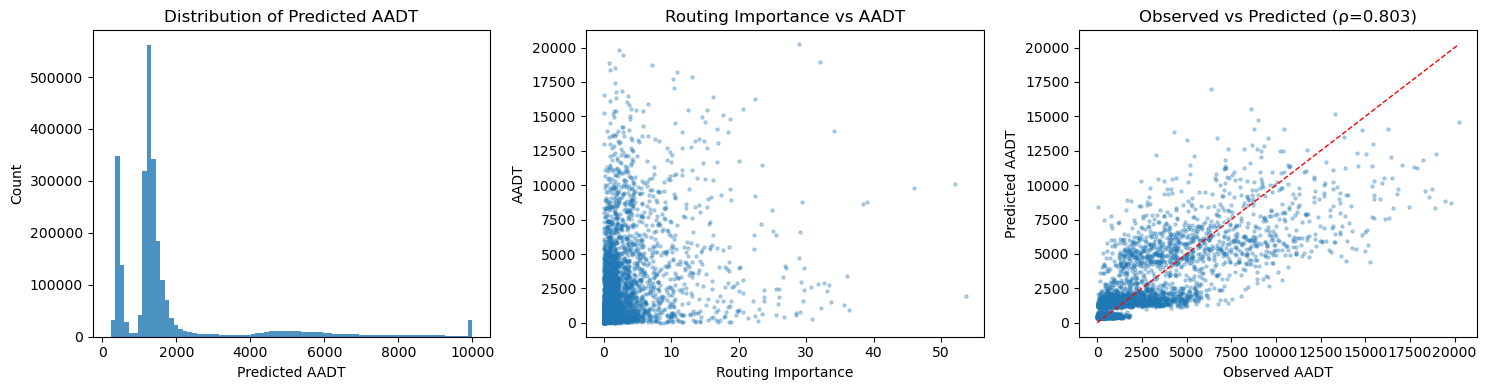

In [22]:
# --- 12.4 Quick diagnostic plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# a) Predicted AADT distribution
axes[0].hist(output['predicted_aadt'].clip(upper=10000), bins=80, edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Predicted AADT')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Predicted AADT')

# b) Routing importance vs predicted AADT
axes[1].scatter(train_clean['routing_importance'], train_clean['aadt'],
                alpha=0.3, s=5, label='Observed')
ri_range = np.linspace(0, train_clean['routing_importance'].quantile(0.99), 100)
axes[1].set_xlabel('Routing Importance')
axes[1].set_ylabel('AADT')
axes[1].set_title('Routing Importance vs AADT')

# c) Observed vs predicted (training set)
train_preds = final_model.predict(X)
axes[2].scatter(y, train_preds, alpha=0.3, s=5)
axes[2].plot([0, y.max()], [0, y.max()], 'r--', lw=1)
axes[2].set_xlabel('Observed AADT')
axes[2].set_ylabel('Predicted AADT')
axes[2].set_title(f'Observed vs Predicted (ρ={np.mean(rhos):.3f})')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aadt_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Clip to West Midlands Study Area

The England-wide predictions are clipped to the seven metropolitan boroughs of the
West Midlands Combined Authority. This WM-specific output is used in subsequent
notebooks for LTS classification.

In [23]:
STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].to_crs(CRS_BNG)
study_area_union = study_area.unary_union

In [25]:
# --- Clip predicted AADT to West Midlands & save ---

# Clip minor roads to study area
wm_minor = all_minor[all_minor.intersects(study_area_union)].copy()
print(f'West Midlands minor road links: {len(wm_minor):,}')

# Save
wm_out = wm_minor[['gid', 'osm_id', 'fclass', 'km',
                     'routing_importance', 'nearest_major_aadt',
                     'is_urban', 'predicted_aadt', 'geom']].copy()
wm_out = wm_out.to_crs(CRS_BNG)

gpkg_path = OUTPUT_DIR / 'wm_minor_road_predicted_aadt.gpkg'
wm_out.to_file(gpkg_path, driver='GPKG')
print(f'Saved: {gpkg_path}')

# Quick summary by road class
print(wm_out.groupby('fclass')['predicted_aadt'].describe()[['count', 'mean', '50%', 'max']].round(0))

West Midlands minor road links: 99,833
Saved: ../Data/Cleaned/wm_minor_road_predicted_aadt.gpkg
                count    mean     50%      max
fclass                                        
residential   70077.0  1367.0  1325.0   2933.0
secondary      6291.0  9904.0  9888.0  18046.0
tertiary      13877.0  5924.0  5841.0  13958.0
unclassified   9588.0  1612.0  1579.0   3306.0


## 14. Close Database Connection

In [26]:
conn.close()
print('Database connection closed.')

Database connection closed.
